<a href="https://colab.research.google.com/github/ratatatan/itmo-oomd/blob/prac4/%D0%9A%D1%83%D1%80%D1%81_%D0%BD%D0%B0_Stepik_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Сделайте копию колаба (файл => создать копию на диске). Переименуйте, добавив в название ФИО и номер группы


# Модуль 5. Частотный анализ изображений

В документе есть ссылки на короткие видео с пояснениями и задание. Оригинально на Степике, это задание оценивалось через peer-review, то есть оценивали по критериям другие студенты. Сейчас этого делать не нужно. Поместите отчет о выполнении задания в конце.

## 5.1 JPEG. Преобразование Фурье. Склейка изображений



Видео урока:

* https://stepik.org/lesson/58410/step/1
* https://stepik.org/lesson/58410/step/2
* https://stepik.org/lesson/58410/step/3
* https://stepik.org/lesson/58410/step/4



## Задание

**Склейка изображений**

В этом задании вам предстоит научиться склеивать изображения с помощью преобразования Фурье.

1. Подготовьте одно изображение для экспериментов с гауссовской и лапласовской пирамидой.

2. Постройте гауссовскую пирамиду изображения из не менее чем пяти слоев. Визуализируйте полученные изображения и амплитуды частот изображений пирамиды (код можно найти в видео про преобразование Фурье) и убедитесь, что на каждом слое диапазон частот сужается. Постройте пирамиду для трех различных значения сигмы гауссовского ядра. Для удобства экспериментирования определите отдельную функцию построения гауссовской пирамиды с параметрами `img` (изображение, по которому строится пирамида), `sigma` (параметр гауссовского ядра), `n_layers` (количество слоев пирамиды), возвращающую списки необходимых изображений.

3. Проведите аналогичные эксперименты с лапласовской пирамидой. Функция для построения лапласовской пирамиды должна использовать функцию построения гауссовской пирамиды и иметь, как и функция гауссовской пирамиды, параметры `img`, `sigma` и `n_layers`.

4. На основе функций построения гауссовской и лапласовской пирамиды напишите функцию склейки двух изображений на основе маски. Функция должна возвращать склееные изображения и промежуточные результаты — склееные изображения разных частот (т.е. лапласовскую пирамиду совмещенного изображения). Изображения для тестирования: [a.png](https://stepik.org/media/attachments/lesson/58410/a.png) , [b.png](https://stepik.org/media/attachments/lesson/58410/b.png), [mask.png](https://stepik.org/media/attachments/lesson/58410/mask.png). Изображение с маской не является бинарным (т.е. имеет промежуточные градации серого), его можно бинаризовать путём сравнения всех элементов с порогом 128:


```
mask = imread('mask.png')
mask = (mask > 128).astype('uint')
```

Посмотрите, как ведет себя склейка при изменении `sigma` (попробуйте три варианта значений при фиксированном количестве слоев в пирамидах) и при изменении количества слоев (попробуйте три варианта слоев при фиксированном `sigma`). Склейка должна выдавать качественный результат без видимых артефактов хотя бы с одним набором параметров.

5. Подготовьте самостоятельно три набора изображений и масок для склейки и визуализируйте результаты функции. У вас должно получиться 3 качественных и интересных коллажа.


In [1]:
! wget -O trees.jpeg -q https://raw.githubusercontent.com/ratatatan/itmo-oomd/refs/heads/prac4/assets/trees.jpeg

In [51]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

def show_grid(rows):
    n_rows = len(rows)
    n_cols = len(max(rows, key=len))
    plt.figure(figsize=(n_cols*3.5, n_rows*5))

    for y, row in enumerate(rows):
        for x, img in enumerate(row):
            plt.subplot(n_rows, n_cols, y * n_cols + x + 1)
            plt.imshow(img)

    plt.show()

In [64]:
import numpy as np
from skimage.color import rgb2ycbcr
from skimage.transform import resize
from skimage.io import imread, imshow
from scipy.ndimage import gaussian_filter
from skimage import img_as_float, img_as_ubyte

def apply_filter(image, filter, *args):
  image = img_as_float(image)

  if len(image.shape) == 2:
    return np.clip(filter(image, *args), 0, 1)
  else:
    return np.clip(
            np.dstack([
              filter(image[:, :, c], *args)
              for c in range(image.shape[2])
            ]), 0, 1)

def get_diff(images):
  return [images[i] - images[i-1] for i in range(1, len(images))]

def get_gaussian_pyramid(image, sigma=1, depth=5):
    pyramid = [image]

    for _ in range(depth-1):
      pyramid.append(apply_filter(pyramid[-1], gaussian_filter, sigma))
      #pyramid.append(gaussian_filter(pyramid[-1], sigma))

    return pyramid

def get_laplacian_pyramid(image, sigma=1, depth=5):
    gaussian_pyramid = get_gaussian_pyramid(image, sigma, depth)

    return [*get_diff(gaussian_pyramid), gaussian_pyramid[-1]]

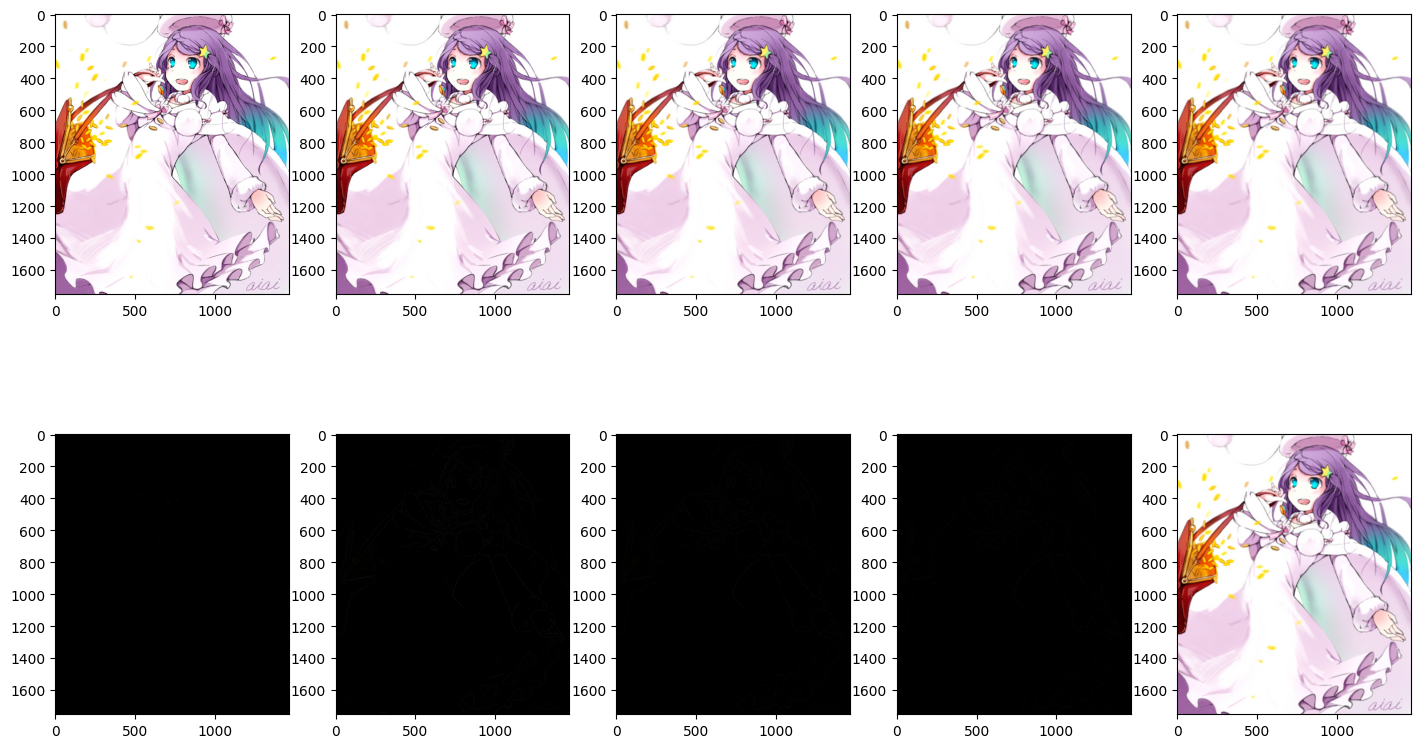

In [65]:
img = imread("nastya.png")

gaussian_pyramid = get_gaussian_pyramid(img)
laplacian_pyramid = get_laplacian_pyramid(img)

show_grid([gaussian_pyramid, laplacian_pyramid])